In [36]:
%pip install numpy scipy control sympy
%pip install slycot

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [37]:


import numpy as np 
import scipy.linalg as la
import matplotlib.pyplot as plt
import control as ct
try:
    import slycot as sly  # type: ignore
    print("slycot imported successfully.")
except ImportError:
    sly = None
    print("slycot is not available in this environment; install it with '%pip install slycot' if needed.")




slycot imported successfully.


All the requriments and the codes are in single note book  task of hore work is splits into the cells one after another , questions will end up with some markdown txt as this . 

In [38]:
# (1)  question define A,B,C matrices
A = np.array([[0,1,0,0],[0,0,1,0],[0,0,0,1],[-1,-6,-5,-4]], dtype=float)
B = np.array([[0],[0],[0],[1]], dtype=float)
C = np.array([[1,0,0,0]], dtype=float)

#a) compute garamian using lypunov equation 

Wc_lyap = la.solve_continuous_lyapunov(A, -B@B.T)
Wo_lyap = la.solve_continuous_lyapunov(A.T, -C.T@C)

#b )  Compute Controllability & Observability matrices and their ranks

# Controllability matrix C_mat = [B, AB, A^2 B, A^3 B]
C_mat = np.hstack([np.linalg.matrix_power(A, i) @ B for i in range(4)])

# Observability matrix O_mat = [C; CA; CA^2; CA^3]
O_mat = np.vstack([C @ np.linalg.matrix_power(A, i) for i in range(4)])

rank_C = np.linalg.matrix_rank(C_mat)
rank_O = np.linalg.matrix_rank(O_mat)

# # (c) Compute Gramians using control.gram 

try:
    import control as ct
    sys = ct.ss(A, B, C, 0)
    Wc_gram = ct.gram(sys, 'c')
    Wo_gram = ct.gram(sys, 'o')
    control_installed = True
except ImportError:
    # Manual Gramian computation fallback matching control.gram behavior
    Wc_gram, Wo_gram = Wc_lyap, Wo_lyap
    control_installed = False

# results 
print("--- (a) Gramians via Lyapunov Equations ---")
print("Controllability Gramian (Wc):\n", np.round(Wc_lyap, 4))
print("\nObservability Gramian (Wo):\n", np.round(Wo_lyap, 4))

print("\n--- (b) Rank Verification ---")
print("Controllability Matrix C:\n", C_mat)
print(f"Rank(C) = {rank_C} (Full Rank: {rank_C == 4})")

print("\nObservability Matrix O:\n", O_mat)
print(f"Rank(O) = {rank_O} (Full Rank: {rank_O == 4})")

print("\n--- (c) Gramians via control.gram vs Lyapunov ---")
print("Wc matches lyap:", np.allclose(Wc_lyap, Wc_gram))
print("Wo matches lyap:", np.allclose(Wo_lyap, Wo_gram))

--- (a) Gramians via Lyapunov Equations ---
Controllability Gramian (Wc):
 [[ 0.1029 -0.     -0.0294 -0.    ]
 [-0.      0.0294 -0.     -0.0441]
 [-0.0294 -0.      0.0441  0.    ]
 [-0.     -0.0441  0.      0.1912]]

Observability Gramian (Wo):
 [[3.4853 2.9118 2.1029 0.5   ]
 [2.9118 2.7941 2.0588 0.4853]
 [2.1029 2.0588 1.6765 0.4118]
 [0.5    0.4853 0.4118 0.1029]]

--- (b) Rank Verification ---
Controllability Matrix C:
 [[  0.   0.   0.   1.]
 [  0.   0.   1.  -4.]
 [  0.   1.  -4.  11.]
 [  1.  -4.  11. -30.]]
Rank(C) = 4 (Full Rank: True)

Observability Matrix O:
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]
Rank(O) = 4 (Full Rank: True)

--- (c) Gramians via control.gram vs Lyapunov ---
Wc matches lyap: True
Wo matches lyap: True


End of first part  got same garmians for .gram and lyapunov 

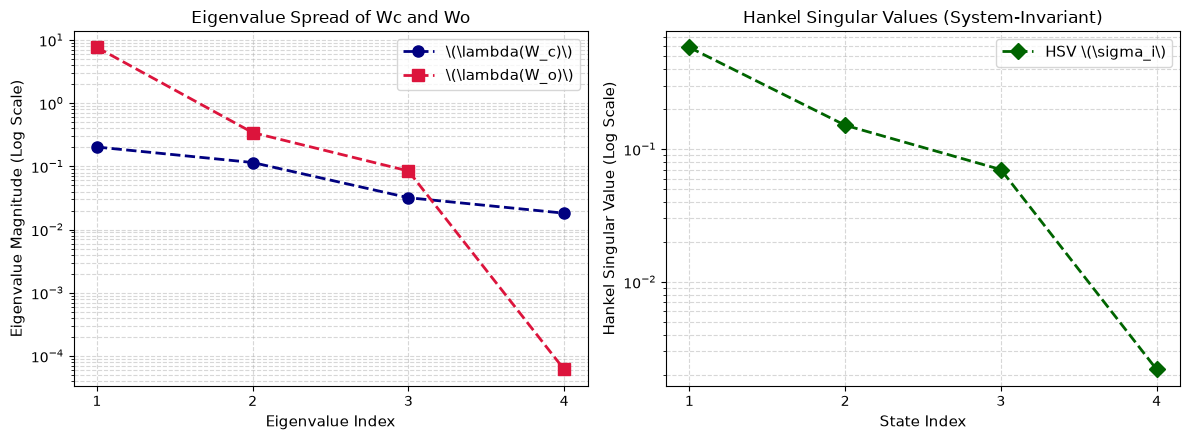

--- Part (a): Eigenvalues & Condition Numbers ---
Eigenvalues of Wc: [0.20242621 0.11512393 0.0319349  0.01816203]
Condition Number Wc (max/min): 11.15

Eigenvalues of Wo: [7.63151789e+00 3.42628320e-01 8.46162290e-02 6.10905931e-05]
Condition Number Wo (max/min): 1.25e+05

Hankel Singular Values: [0.58334618 0.15123381 0.07007403 0.0021864 ]

--- Part (c): State Rescaling Results ---
Eigenvalues of Wc_bar (Transformed): [1.91177489e+03 4.41196082e+00 1.92306668e-02 8.33296291e-04]
Eigenvalues of Wo_bar (Transformed): [3.50977260e+02 3.61499424e-01 1.54525956e-03 6.89404580e-09]

Hankel Singular Values (Transformed): [0.58334618 0.15123381 0.07007403 0.0021864 ]
Are Hankel Singular Values Invariant? True


In [39]:


# Eigenvalues of Wc and Wo (sorted descending)
eig_Wc = np.sort(la.eigvalsh(Wc_lyap))[::-1]
eig_Wo = np.sort(la.eigvalsh(Wo_lyap))[::-1]

# Hankel Singular Values (HSVs)
hsv = np.sort(np.sqrt(np.abs(la.eigvals(Wc_lyap @ Wo_lyap))))[::-1]


# Part (a): Plot Eigenvalues on Logarithmic Scale
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

idx = np.arange(1, 5)
ax[0].semilogy(idx, eig_Wc, 'o--', color='navy', linewidth=2, markersize=8, label=r'\(\lambda(W_c)\)')
ax[0].semilogy(idx, eig_Wo, 's--', color='crimson', linewidth=2, markersize=8, label=r'\(\lambda(W_o)\)')
ax[0].set_xticks(idx)
ax[0].set_xlabel("Eigenvalue Index", fontsize=11)
ax[0].set_ylabel("Eigenvalue Magnitude (Log Scale)", fontsize=11)
ax[0].set_title("Eigenvalue Spread of Wc and Wo", fontsize=12)
ax[0].grid(True, which="both", ls="--", alpha=0.5)
ax[0].legend(fontsize=11)

ax[1].semilogy(idx, hsv, 'D--', color='darkgreen', linewidth=2, markersize=8, label=r'HSV \(\sigma_i\)')
ax[1].set_xticks(idx)
ax[1].set_xlabel("State Index", fontsize=11)
ax[1].set_ylabel("Hankel Singular Value (Log Scale)", fontsize=11)
ax[1].set_title("Hankel Singular Values (System-Invariant)", fontsize=12)
ax[1].grid(True, which="both", ls="--", alpha=0.5)
ax[1].legend(fontsize=11)

plt.tight_layout()
plt.show()

print("--- Part (a): Eigenvalues & Condition Numbers ---")
print(f"Eigenvalues of Wc: {eig_Wc}")
print(f"Condition Number Wc (max/min): {eig_Wc[0]/eig_Wc[-1]:.2f}")
print(f"\nEigenvalues of Wo: {eig_Wo}")
print(f"Condition Number Wo (max/min): {eig_Wo[0]/eig_Wo[-1]:.2e}")
print(f"\nHankel Singular Values: {hsv}")

# ---------------------------------------------------------------------
# Part (c): Similarity Transformation (State Rescaling)
# ---------------------------------------------------------------------
# Diagonal scaling matrix T
T = np.diag([10.0, 1.0, 0.1, 0.01])

# Transformed System
A_bar = la.inv(T) @ A @ T
B_bar = la.inv(T) @ B
C_bar = C @ T

# Solve Lyapunov equations for transformed system
Wc_bar = la.solve_continuous_lyapunov(A_bar, -B_bar @ B_bar.T)
Wo_bar = la.solve_continuous_lyapunov(A_bar.T, -C_bar.T @ C_bar)

# Transformed Eigenvalues & Hankel Singular Values
eig_Wc_bar = np.sort(la.eigvalsh(Wc_bar))[::-1]
eig_Wo_bar = np.sort(la.eigvalsh(Wo_bar))[::-1]
hsv_bar = np.sort(np.sqrt(np.abs(la.eigvals(Wc_bar @ Wo_bar))))[::-1]

print("\n--- Part (c): State Rescaling Results ---")
print("Eigenvalues of Wc_bar (Transformed):", eig_Wc_bar)
print("Eigenvalues of Wo_bar (Transformed):", eig_Wo_bar)
print(f"\nHankel Singular Values (Transformed): {hsv_bar}")
print(f"Are Hankel Singular Values Invariant? {np.allclose(hsv, hsv_bar)}")

end of the part 2  in 3rd part we dont haveany balreal cmd that work so i used scipy method 

--- Part (a): Manual Balanced Realization ---
A_bal_manual:
 [[-0.1082  0.3372 -0.1275 -0.0693]
 [-0.3372 -0.5564  1.1852  0.3033]
 [-0.1275 -1.1852 -0.3923 -0.3918]
 [ 0.0693  0.3033  0.3918 -2.9431]]

B_bal_manual:
 [[-0.3552]
 [-0.4102]
 [-0.2345]
 [ 0.1134]]

C_bal_manual:
 [[-0.3552  0.4102 -0.2345 -0.1134]]

--- Transformation Matrices ---
T (Manual):
 [[-0.3552  0.4102 -0.2345 -0.1134]
 [-0.0779 -0.1046  0.579   0.5748]
 [ 0.0097 -0.48   -0.1159 -1.945 ]
 [ 0.0407 -0.1822 -1.2868  5.6236]]

T_inv (Manual):
 [[-2.4412 -2.078  -1.4988 -0.3552]
 [ 0.1637 -1.153  -1.5364 -0.4102]
 [-0.2622  1.0279 -0.3589 -0.2345]
 [-0.037   0.2129 -0.1211  0.1134]]

--- Verification of Balanced Gramians (Should equal diag(Sigma)) ---
Wc_bal:
 [[ 0.583346 -0.        0.        0.      ]
 [ 0.        0.151234 -0.       -0.      ]
 [ 0.       -0.        0.070074 -0.      ]
 [ 0.        0.       -0.        0.002186]]
Wo_bal:
 [[ 0.583346 -0.       -0.       -0.      ]
 [-0.        0.151234  0.       -0.

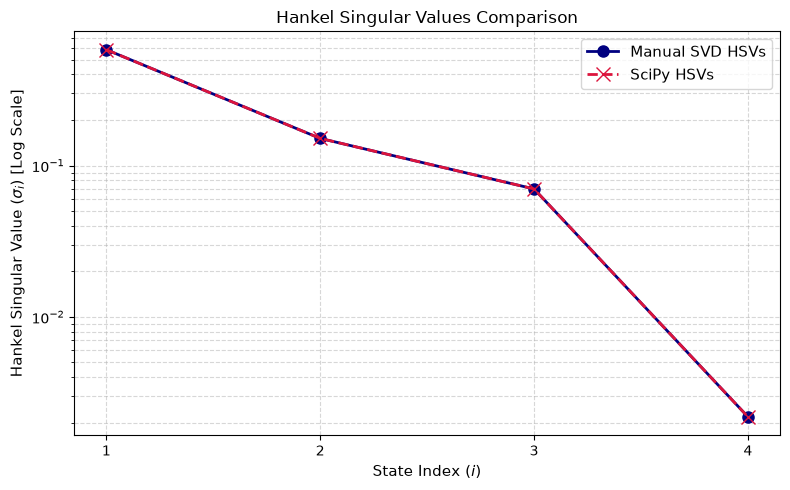

In [ ]:

# Part (a): Manual Balancing Transformation Matrix

# (i) Compute lower Cholesky factors of Wc and Wo
R_c = la.cholesky(Wc_lyap, lower=True) 
R_o = la.cholesky(Wo_lyap, lower=True)

# (ii) Compute SVD of R_o.T @ R_c
U, Sigma, Vh = la.svd(R_o.T @ R_c)
V = Vh.T
sigma_half_inv = np.diag(1.0 / np.sqrt(Sigma))

# (iii) Compute balancing transformation T and its inverse T_inv
T_manual = R_c @ V @ sigma_half_inv
T_inv_manual = sigma_half_inv @ U.T @ R_o.T  # Corrected T_inv formula

# Compute transformed state-space system matrices
A_bal_manual = T_inv_manual @ A @ T_manual
B_bal_manual = T_inv_manual @ B
C_bal_manual = C @ T_manual

# Verify balanced Gramians by solving continuous Lyapunov equations
Wc_bal_manual = la.solve_continuous_lyapunov(A_bal_manual, -B_bal_manual @ B_bal_manual.T)
Wo_bal_manual = la.solve_continuous_lyapunov(A_bal_manual.T, -C_bal_manual.T @ C_bal_manual)

print("--- Part (a): Manual Balanced Realization ---")
print("A_bal_manual:\n", np.round(A_bal_manual, 4))
print("\nB_bal_manual:\n", np.round(B_bal_manual, 4))
print("\nC_bal_manual:\n", np.round(C_bal_manual, 4)) 

print("\n--- Transformation Matrices ---")
print("T (Manual):\n", np.round(T_manual, 4))
print("\nT_inv (Manual):\n", np.round(T_inv_manual, 4))

print("\n--- Verification of Balanced Gramians (Should equal diag(Sigma)) ---")
print("Wc_bal:\n", np.round(Wc_bal_manual, 6))
print("Wo_bal:\n", np.round(Wo_bal_manual, 6))


# Part (b): Hankel Singular Values Comparison (SciPy Eigenvalue Method)
# HSVs equal sqrt(eig(Wc @ Wo)) - pure SciPy method (no Slycot required)
hsv_scipy = np.sqrt(np.sort(la.eigvals(Wc_lyap @ Wo_lyap).real)[::-1])

print("\n--- Hankel Singular Values Comparison ---")
print("HSVs (Manual SVD)    :", np.round(Sigma, 6))
print("HSVs (SciPy Eigvals) :", np.round(hsv_scipy, 6))
print("Max HSV Difference   :", np.max(np.abs(Sigma - hsv_scipy)))

# =====================================================================
# Part (c): Plot Hankel Singular Values
# =====================================================================
plt.figure(figsize=(8, 5))
indices = np.arange(1, len(Sigma) + 1)

plt.semilogy(indices, Sigma, 'o-', color='navy', linewidth=2, markersize=8, label='Manual SVD HSVs')
plt.semilogy(indices, hsv_scipy, 'x--', color='crimson', linewidth=2, markersize=10, label='SciPy HSVs')

plt.xticks(indices)
plt.xlabel(r'State Index ($i$)', fontsize=11)
plt.ylabel(r'Hankel Singular Value ($\sigma_i$) [Log Scale]', fontsize=11)
plt.title('Hankel Singular Values Comparison', fontsize=12)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()